# PREPARAZIONE DELL'AMBIENTE E IMPORTAZIONI

Come primo step vado ad installare le librerie necessarie per lo sviluppo del progetto e a collegare il mio Google Drive dove ho caricato il dataset.

In [1]:
# Installo le librerie necessarie
!pip install timm

# Importo i pacchetti
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from timm import create_model
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.metrics import f1_score, confusion_matrix
import seaborn as sns
from google.colab import drive
from typing import Tuple


In [2]:
# Monto di Google Drive
drive.mount('/content/drive')

# Mi posiziono all'interno della cartella del progetto
%cd /content/drive/MyDrive/Colab Notebooks/GreenTech Solutions

# Estraggo il dataset
# Mediante il comando tar vado a scompattare la cartella WinRAR caricata
if not os.path.exists('dataset'):
    print("Estrazione in corso")
    !tar -xvf progetto-finale-flowes.tar.gz
    print("Estrazione completata!")
else:
    print("Dataset già presente, estrazione non necessaria.")

# Definisco i percorsi per le fasi successive
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/GreenTech Solutions/progetto-finale-flowes'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'valid')
TEST_DIR = os.path.join(DATA_DIR, 'test')

# Verifico che sia tutto funzionante
if os.path.exists(TRAIN_DIR):
    print(f"Cartelle trovate in: {DATA_DIR}")
    print(f"Classi disponibili: {os.listdir(TRAIN_DIR)}")
else:
    print("Errore: cartella 'train'non trovata.")

Output streaming troncato alle ultime 5000 righe.
progetto-finale-flowes/train/dandelion/._2494436687_775402e0aa_jpg.rf.acff7c2762f4a0254086e0efd5c91289.jpg
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
progetto-finale-flowes/train/dandelion/2494436687_775402e0aa_jpg.rf.acff7c2762f4a0254086e0efd5c91289.jpg
progetto-finale-flowes/train/dandelion/._34571561452_07ec474366_n_jpg.rf.e81fd0673a8b2d7def1c06e8c223665b.jpg
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
progetto-finale-flowes/train/dandelion/34571561452_07ec474366_n_jpg.rf.e81fd0673a8b2d7def1c06e8c223665b.jpg
progetto-finale-flowes/train/dandelion/._9111669902_9471c3a49c_n_jpg.rf.22355a28d0264a200e46fb7f8ea2c330.jpg
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
progetto-finale-flowes/train/dandelion/9111669902_9471c3a49c_n_jpg.rf.22355a28d0264a200e46fb7f8ea2c330.jpg
progetto-finale-flowes/train/dandelion/._33877

# DEFINIZIONE DEL DATASET E CARICAMENTO DATI

Dopo aver preparato l'ambiente, ho pensato a un sistema per collegare le immagini salvate su disco e il modello di Deep Learning. Per farlo, ho implementato una classe personalizzata chiamata FlowerDataset.

L'idea alla base di questa scelta è quella di non caricare tutto il dataset contemporaneamente (cosa che saturerebbe subito la memoria RAM), ma di istruire il sistema a leggere le immagini solo quando servono effettivamente per l'addestramento. Durante questa fase, ho notato la presenza di file di sistema nascosti (come quelli generati dai sistemi Mac) che avrebbero potuto interrompere il processo. Per questo motivo, c'è un filtro per prendere solo le immagini aventi estensione corretta.

Nello specifico, la classe si occupa di tre compiti fondamentali:
-mappa le categorie: traduce i nomi delle cartelle ("daisy" e "dandelion") nei valori numerici 0 e 1, che sono gli unici comprensibili dalla rete neurale.
-gestisce l'inventario: considera il numero totale di foto disponibili al fine di organizzare correttamente i cicli di addestramento.
-prepara l'immagine: ogni volta che viene richiesta una foto, questa viene aperta, convertita nel in formato RGB e preparata per subire le trasformazioni necessarie a simulare diverse condizioni ambientali.

In [3]:
class FlowerDataset(Dataset):
    """Dataset personalizzato pensato per ignorare i file di sistema Mac"""

    EXTENSIONS = ("jpg", "jpeg", "png", "tif", "tiff")

    def __init__(self, data_dir, class_map, transform=None):
        self.data_dir = data_dir
        self.class_map = class_map
        self.transform = transform
        self.images, self.labels = self._load_samples()

    def _load_samples(self):
        images, labels = [], []
        for label, class_names in self.class_map.items():
            for class_name in class_names:
                class_path = os.path.join(self.data_dir, class_name)
                # Verifico che sia una cartella reale e non un file nascosto
                if os.path.isdir(class_path) and not class_name.startswith('.'):
                    for f in os.listdir(class_path):
                        # Filtro critico: utilizzato per ignorare i files che iniziano con '._'
                        if not f.startswith('.') and f.split(".")[-1].lower() in self.EXTENSIONS:
                            images.append(os.path.join(class_path, f))
                            labels.append(label)
        return images, labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

# CHECK SUL CORRETTO CARICAMENTO SUI DATI

In questa sezione effettuo un check sul funzionamento della classe FlowerDataset. Estraggo un'immagine casuale dal dataset e la vado a mostrare a schermo. Questo passaggio è fondamentale per alcuni motivi: mi consente di verificare che all'etichetta numerica (0 o 1) corrisponda effettivamente il fiore corretto (margherita o tarassaco); mi serve per confermare che il formato dei tensori sia compatibile con quanto richiesto dal modello (3 canali); mi consente di accertare che il sistema riesca ad aprire correttamente i file su Google Drive senza errori di lettura.

Image index: 1005
Immagine convertita in Tensor
torch.Size([3, 512, 512]) 1 ['dandelion']
(512, 512, 3) Label: dandelion


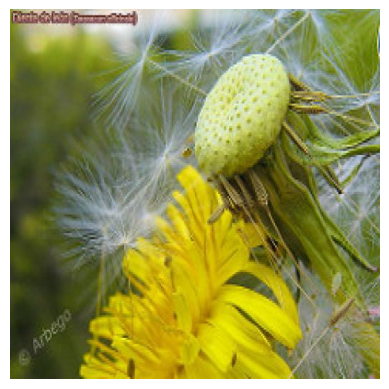

In [4]:
# Definisco la mappa delle classi per l'interpretazione dei risultati
class_map = {0: ['daisy'], 1: ['dandelion']}

# Definisco il dataset senza trasformazioni per vedere l'immagine originale
# Usiamo TRAIN_DIR che abbiamo definito negli step precedenti
dataset = FlowerDataset(data_dir=TRAIN_DIR, class_map=class_map, transform=None)

# Seleziono un indice casuale per il test
idx = random.randint(0, len(dataset) - 1)
print(f"Image index: {idx}")


# Estraggo l'immagine e l'etichetta corrispondente
image, label = dataset[idx]

# Se l'immagine è in formato PIL (perché transform=None), la converto in Tensore per usare .shape e .permute

if not torch.is_tensor(image):
    from torchvision.transforms import functional as F
    image = F.to_tensor(image)
    print("Immagine convertita in Tensor")

# Illustro i dettagli tecnici : forma del tensore, etichetta numerica e nome classe
# Il formato PyTorch è così costituito : (Canali, Altezza, Larghezza)
print(image.shape, label, class_map[label])

# Effettuo il plot dell'immagine
# Trasformo l'immagine in modo da renderla leggibile per Matplotlib
image = image.permute(1, 2, 0).numpy()

# Visualizzazione finale
print(image.shape, f"Label: {class_map[label][0]}")
plt.imshow(image)
plt.axis('off') # Nascondo gli assi per una visualizzazione più pulita
plt.show()

#

# DEFINIZIONE DELLE TRASFORMAZIONI E PREPARAZIONE DEI DATASET FINALI (CON CHECK MEDIANTE RAPPRESENTAZIONE VISIVA)

In questa fase vado a definire le logiche di pre-elaborazione delle immagini che verranno fornite alla rete neurale.

Per il set di addestramento (Training), ho scelto di adottare una strategia di Data Augmentation piuttosto dinamica. L'obiettivo è quello di sottoporre al modello versioni sempre diverse della stessa immagine (applicando rotazioni, specchiature e variazioni di luminosità) per simulare l'imprevedibilità dell'ambiente esterno.
Per i set di Validazione e Test, invece, le trasformazioni sono volutamente più rigide (semplice ridimensionamento e ritaglio centrale). In questo modo la valutazione delle performance avviene su dati standardizzati e ciò consente di misurare l'accuratezza del modello in modo oggettivo e coerente.

In [5]:
# Configuro la Data Augmentation per l'addestramento
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224), # Ritaglio casuale a 224x224 per focalizzarsi su diverse parti del fiore
    transforms.RandomHorizontalFlip(p=0.5), # flip casuale per slegare il riconoscimento dalla direzione
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.1), # Variazioni di luce e colore
    transforms.RandomRotation(degrees=10), # Rotazione casuale di massimo 10 gradi
    transforms.ToTensor(), # Conversione in formato Tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standardizzazione ImageNet, che verrà utilizzato successivamente nel codice
])

# Configuro le trasformazioni per Validazione e Test
val_transform = transforms.Compose([
    transforms.Resize(256), # Ridimensionamento base
    transforms.CenterCrop(224), # Ritaglio del quadrato centrale perfetto
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Applico le trasformazioni ai rispettivi set di dati
train_dataset = FlowerDataset(data_dir=TRAIN_DIR, class_map=class_map, transform=train_transform)
val_dataset = FlowerDataset(data_dir=VAL_DIR, class_map=class_map, transform=val_transform)
test_dataset = FlowerDataset(data_dir=TEST_DIR, class_map=class_map, transform=val_transform)


Per concludere la fase di preparazione, implemento una funzione di visualizzazione massiva. Effettuo questo test di rappresentazione per verificare il corretto funzionamento delle trasformazioni effettuate e assicurarmi che, malgrado le alterazioni introdotte dalla Data Augmentation, i fiori rimangano chiaramente riconoscibili. Questo controllo visivo è fondamentale per validare che i parametri scelti siano idonei e non alterino eccessivamente l'informazione necessaria al modello per apprendere.

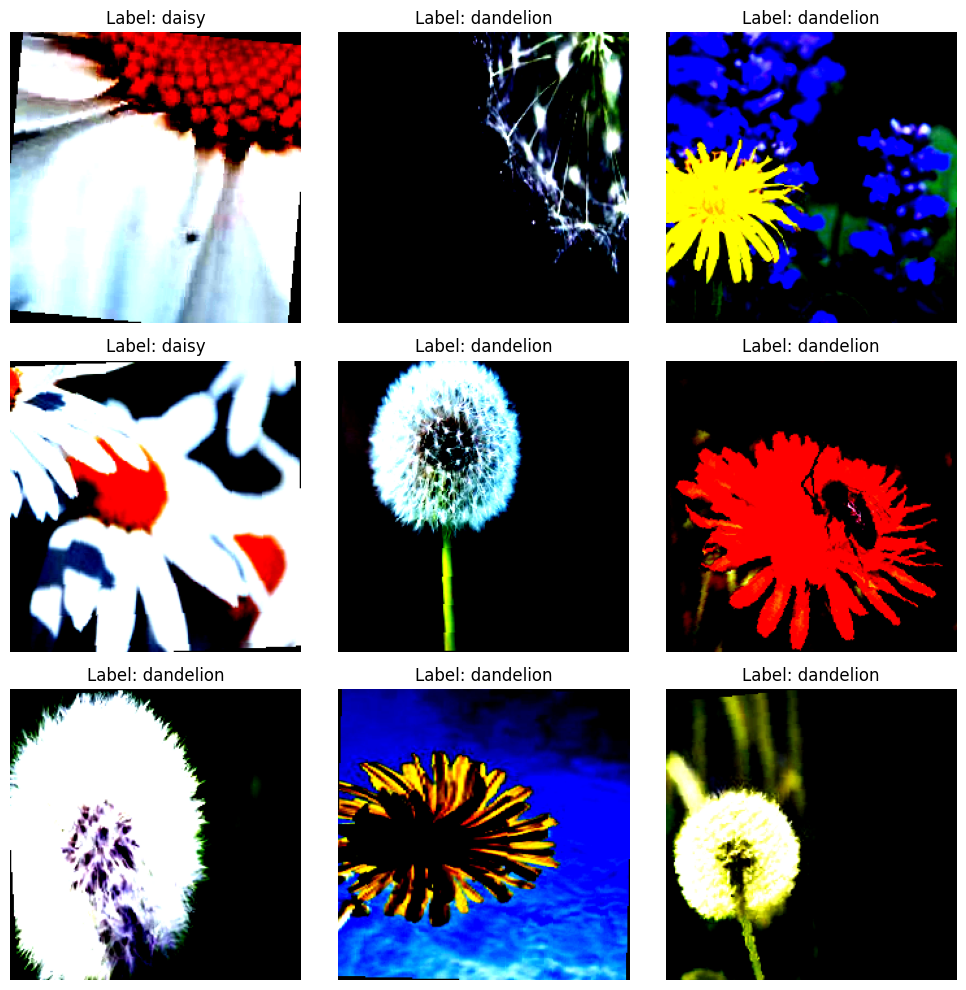

In [6]:
from typing import Dict, List #<-- prevengo Name Error


def plot_images(dataset: FlowerDataset, class_map: Dict[int, List[str]], rows: int = 3, cols: int = 3) -> None:
    """
    Estrae e visualizza immagini casuali dal dataset per verificare
    il mapping e l'effetto delle trasformazioni.

    Args:
        dataset (FlowerDataset): Il dataset da cui estrarre le immagini.
        class_map (Dict[int, List[str]]): Mappatura delle classi ricondotte ai rispettivi nomi.
        rows (int, opzionale): Numero di righe da visualizzare, impostato a 3 di default.
        cols (int, opzionale): Numero di colonne da visualizzare, impostato a 3 di default.
    """
    fig, axes = plt.subplots(rows, cols, figsize=(10, 10))
    for i in range(rows):
        for j in range(cols):
            # Seleziono in modo casuale un indice
            idx = random.randint(0, len(dataset) - 1)
            image, label = dataset[idx]

            # Converto da formato PyTorch (C, H, W) a formato Matplotlib (H, W, C)
            image = image.permute(1, 2, 0).numpy()

            # Clip dei valori per correggere l'effetto della normalizzazione nel plot --> alcuni valori potrebbero essere eccessivi ed il clip li taglia
            image = image.clip(0, 1)

            # Configuro il sotto-grafico
            axes[i, j].imshow(image)
            axes[i, j].set_title(f"Label: {class_map[label][0]}")
            axes[i, j].axis('off') # Rimuovo gli assi per chiarezza visiva

    plt.tight_layout()
    plt.show()

# Eseguo il test sul dataset di addestramento per vedere le trasformazioni in azione
plot_images(train_dataset, class_map)

# CONFIGURAZIONE DEI DATALOADER E GESTIONE DEI BATCH

In questa fase vado a definire i DataLoader, per prelevare le immagini dal dataset e organizzarle in batch. Ho scelto una dimensione di batch pari a 32: questo valore rappresenta un ottimo equilibrio tra efficienza computazionale e stabilità durante l'aggiornamento dei pesi del modello.

Per il set di addestramento, ho attivato l'opzione shuffle=True per rimescolare l'ordine delle foto a ogni epoca. Facendo così, il modello non impara la sequenza dei dati ma si focalizza sulle caratteristiche visive dei fiori. Concludo questa sezione con un rapido test di controllo per verificare che la struttura dei dati in uscita sia corretta (32 immagini per ogni batch, ciascuna con i suoi 3 canali colore).

In [7]:
# Configurazione dei DataLoader
# Batch_size=32 significa che il modello vedrà 32 immagini alla volta
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Test di verifica: controlliamo cosa produce effettivamente il dataloader
# Questo loop si ferma subito dopo il primo batch (break)
for batch in train_loader:
    x, target = batch # x sono le immagini, target sono le etichette (0 o 1)

    print(f"Forma del batch di immagini (x): {x.shape}")
    # Output atteso: [32, 3, 224, 224] -> (Batch, Canali, Altezza, Larghezza)

    print(f"Forma del batch di etichette (target): {target.shape}")
    # Output atteso: [32] -> un'etichetta per ogni immagine del batch

    break

Forma del batch di immagini (x): torch.Size([32, 3, 224, 224])
Forma del batch di etichette (target): torch.Size([32])


# SETUP DEL MODELLO RESNET18 MEDIANTE TIMM

In questa sezione vado a inizializzare l'architettura del modello. Uso la libreria timm (PyTorch Image Models), uno standard nel settore che ci consente di accedere a modelli che costituiscono stato dell'arte. La mia scelta è stata una ResNet18 pre-addestrata: questo modello ha già imparato a riconoscere forme e caratteristiche su milioni di immagini (ImageNet) ed ora vado ad orientarlo verso il riconoscimento dei fiori di mio interesse tramite il Transfer Learning.

Andando a specificare num_classes=2, porto il modello ad adattare automaticamente il suo strato finale al fine di classificare esclusivamente le nostre due categorie (Margherita e Tarassaco). Fatto ciò, sposto il modello sulla GPU per garantire la massima velocità durante la fase di training.

In [8]:
# Ci si deve accertare di avere in Runtime su GPU
# Creo il modello con timm
# num_classes=2 adatta automaticamente l'ultimo strato per il nostro dataset
# pretrained=True mi consente di caricare i pesi già ottimizzati su ImageNet
model = create_model("resnet18", num_classes=2, pretrained=True)

# Trasferisco il modello sulla GPU per accelerare i calcoli
model.to("cuda")

print("Modello ResNet18 configurato correttamente e caricato su CUDA.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Modello ResNet18 configurato correttamente e caricato su CUDA.


# CONFIGURAZIONE DI LOSS, OPTIMIZER E LEARNING RATE SCHEDULER
In questa sezione vado a definire alcuni aspetti fondamentali per il progetto:

-Loss Function: la mia scelta è ricaduta sulla CrossEntropyLoss, lo standard per i problemi di classificazione, utile a misurare la distanza tra le previsioni del modello e le etichette reali.

-Optimizer: per questo progetto ho deciso di utilizzare Adam, ottimizzatore che adatta automaticamente il tasso di apprendimento per ogni parametro.

-Scheduler: ho ritenuto opportuno utilizzare CosineAnnealingLR. Ciò mi consente di ridurre il Learning Rate seguendo una curva cosinoidale, permettendo al modello di esplorare rapidamente i dati all'inizio e di concentrarsi su una definizione puntuale dei pesi nelle fasi finali.

Eseguo infine una simulazione visiva per verificare che l'andamento del Learning Rate segua correttamente la curva prevista durante le epoche di addestramento.

Numero iterazioni per epoca: 40


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


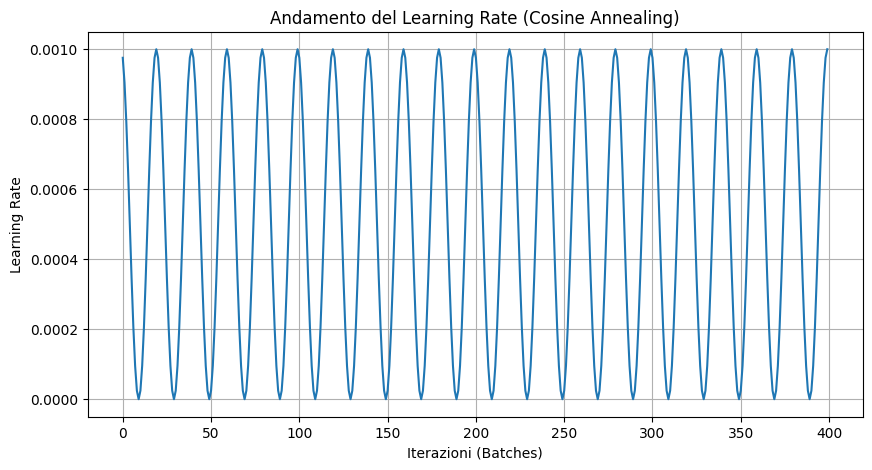

In [9]:
# Definisco la funzione di Loss
loss_fn = nn.CrossEntropyLoss()
loss_fn.to("cuda")

# Definisco l'ottimizzatore con Learning Rate iniziale di 0.001
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Configurazione lo Scheduler (Cosine Annealing)
# T_max rappresenta il numero di iterazioni per portare il LR dal suo valore massimo al minimo e coincide con il numero di epoche che andrò ad utilizzare, per una perfetta sincronizzazione
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Simulo e rappresento graficamente lo scheduler per verificarne l'andamento
print(f"Numero iterazioni per epoca: {len(train_loader)}")
epochs = 10
lr_values = []

# Simulo il passaggio delle epoche per vedere come cambia il Learning Rate
for epoch in range(epochs):
    for _ in range(len(train_loader)):
        scheduler.step()
        lr_values.append(scheduler.get_last_lr()[0])

# Visualizzo della curva del Learning Rate
plt.figure(figsize=(10, 5))
plt.plot(lr_values)
plt.title("Andamento del Learning Rate (Cosine Annealing)")
plt.xlabel("Iterazioni (Batches)")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.show()

# DEFINIZIONE DEL CICLO DI ADDESTRAMENTO E VALIDAZIONE

In questa fase vado a definire le funzioni che gestiranno l'apprendimento del modello.

La funzione train_epoch consente alla rete di apprendere e migliorare dai propri errori mediante la backpropagation che agisce sulla correzione dei pesi interni.Ho inserito anche un sistema di logging per monitorare l'andamento della Loss e del Learning Rate in tempo reale durante ogni iterazione.

La funzione validation_epoch, invece, serve a testare il modello su dati che non ha mai visto durante l'addestramento. In questa fase, disattivo il calcolo dei gradienti (utlizzando torch.no_grad()) per risparmiare memoria e assicurarmi che il modello non "impari" dai dati di test. Per valutare le prestazioni, oltre alla perdita, calcolo il F1-Score, una metrica molto più affidabile della semplice accuratezza quando si lavora in contesti di classificazione binaria.

In [10]:
def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
    optimizer: optim.Optimizer,
    scheduler: optim.lr_scheduler,
    device: torch.device,
    log_every: float = 0.1
) -> Tuple[float, float]:
    """Alleno il modello per una singola epoca.

    Args:
        model (nn.Module): modello PyTorch
        loader (DataLoader): DataLoader di PyTorch
        loss_fn (nn.Module): Funzione di Loss
        optimizer (optim.Optimizer): Optimizer
        scheduler (optim.lr_scheduler): Scheduler per il Learning Rate
        device (torch.device): device di PyTorch (CPU o GPU)
        log_every (float, optional): Frequenza del logging, impostata di default a 0.1

    Returns:
        Tuple[float, float]: Loss e F1-score della epoca
    """


    model.train() # Imposto il modello in modalità addestramento
    running_loss = 0.0
    all_preds, all_targets = [], []
    log_every_iters = int(len(loader) * log_every)

    for idx, batch in enumerate(loader):
        x, target = batch
        x, target = x.to(device), target.to(device) # Sposto i dati su GPU

        optimizer.zero_grad()    # Resetto i gradienti precedenti
        output = model(x)        # Forward pass: il modello fa una previsione
        loss = loss_fn(output, target) # Calcolo dell'errore
        loss.backward()          # Backpropagation: calcolo del gradiente
        optimizer.step()         # Aggiorno i pesi
        scheduler.step()         # Aggiorno del Learning Rate

        running_loss += loss.item()
        # Salvo le predizioni per calcolare F1-score alla fine
        all_preds.extend(output.argmax(1).cpu().numpy())
        all_targets.extend(target.cpu().numpy())

        # Log periodico per monitorare i progressi
        if (idx+1) % log_every_iters == 0:
            print(f"> Train iter [{idx+1}/{len(loader)}] - loss={running_loss/(idx+1):.5f}, lr={scheduler.get_last_lr()[0]:.5f}")

    loss = running_loss / len(loader)
    f1 = f1_score(all_targets, all_preds)
    return loss, f1

def validation_epoch(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
    device: torch.device
) -> Tuple[float, float]:
    """Valuto il modello sul set di validazione.

    Args:
        model (nn.Module): modello di PyTorch
        loader (DataLoader): DataLoader di PyTorch
        loss_fn (nn.Module): Funzione di Loss
        device (torch.device): device di PyTorch (CPU o GPU)

    Returns:
        Tuple[float, float]: Loss e F1-score della validazione
    """

    model.eval() # Imposta il modello in modalità valutazione (disattiva Dropout, etc.)
    running_loss = 0.0
    all_preds, all_targets = [], []

    with torch.no_grad(): # Disattiva il calcolo dei gradienti per efficienza
        for batch in loader:
            x, target = batch
            x, target = x.to(device), target.to(device)

            output = model(x)
            loss = loss_fn(output, target)

            running_loss += loss.item()
            all_preds.extend(output.argmax(1).cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    loss = running_loss / len(loader)
    f1 = f1_score(all_targets, all_preds)
    return loss, f1

# ESECUZIONE DEL TRAINING E VALUTAZIONE FINALE SUL TEST SET

In questa sezione si passa alla parte nevralgica del progetto. Ho deciso di eseguire l'addestramento per 10 epoche, richiamando per ogni ciclo le funzioni di training e validazione definite in precedenza. Ho impostato la frequenza del logging a 0.05, il che mi permette di monitorare l'andamento del modello con una livello di dettaglio del 5% per ogni epoca.

Al termine delle 10 epoche, eseguo un test fondamentale: la valutazione sul Test Set. Questi dati rappresentano il "mondo reale" per il modello impostato, poiché nuovi rispetto a quelli utilizzati per addestramento. I risultati in termini di Loss e F1-Score ottenuti sul set di test saranno l'indicatore definitivo dell'affidabilità del sistema prima del suo reale effettivo impiego.


In [11]:
# Resetto Optimizer e Scheduler per farli ripartire da zero
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

# Configuro DataLoader e parametri
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
log_every = 0.05
device = "cuda"
EPOCHS = 10

# Ciclo di addestramento
for epoch in range(EPOCHS):
    print(f"\n******** Epoca {epoch+1}/{EPOCHS} ********")

    # Fase di addestramento
    train_loss, train_f1 = train_epoch(
        model=model, loss_fn=loss_fn, loader=train_loader,
        optimizer=optimizer, scheduler=scheduler,
        device=device, log_every=log_every
    )

    # Fase di validazione
    val_loss, val_f1 = validation_epoch(
        model=model, loss_fn=loss_fn, loader=val_loader, device=device
    )

    # Riepilogo i risultati dell'epoca
    print(f"> Riepilogo Epoca: \n\t- train_loss={train_loss:.5f}\n\t- train_f1={train_f1:.5f} \n\t- val_loss={val_loss:.5f}\n\t- val_f1={val_f1:.5f}")

# Effettuo una valutazione finale sul test set
test_dataset = FlowerDataset(data_dir=TEST_DIR, class_map=class_map, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32)

test_loss, test_f1 = validation_epoch(
    model=model, loss_fn=loss_fn, loader=test_loader, device=device
)

print("\n" + "="*35)
print(f"   RISULTATI FINALI SUL TEST SET:")
print(f"   Test Loss: {test_loss:.5f}")
print(f"   Test F1-Score: {test_f1:.5f}")
print("="*35)


******** Epoca 1/10 ********
> Train iter [2/40] - loss=0.67700, lr=0.00090
> Train iter [4/40] - loss=0.64306, lr=0.00065
> Train iter [6/40] - loss=0.60859, lr=0.00035
> Train iter [8/40] - loss=0.60331, lr=0.00010
> Train iter [10/40] - loss=0.58155, lr=0.00000
> Train iter [12/40] - loss=0.57394, lr=0.00010
> Train iter [14/40] - loss=0.57379, lr=0.00035
> Train iter [16/40] - loss=0.56393, lr=0.00065
> Train iter [18/40] - loss=0.55233, lr=0.00090
> Train iter [20/40] - loss=0.54172, lr=0.00100
> Train iter [22/40] - loss=0.52122, lr=0.00090
> Train iter [24/40] - loss=0.50679, lr=0.00065
> Train iter [26/40] - loss=0.48923, lr=0.00035
> Train iter [28/40] - loss=0.47485, lr=0.00010
> Train iter [30/40] - loss=0.46135, lr=0.00000
> Train iter [32/40] - loss=0.44976, lr=0.00010
> Train iter [34/40] - loss=0.44204, lr=0.00035
> Train iter [36/40] - loss=0.43282, lr=0.00065
> Train iter [38/40] - loss=0.42107, lr=0.00090
> Train iter [40/40] - loss=0.41469, lr=0.00100
> Riepilogo Ep

# ANALISI DEI RISULTATI E VISUALIZZAZIONE DEGLI ERRORI

In questa fase finale vado ad approfondire l'analisi delle performance del modello sul set di test. Ho utilizzato un approccio basato su tre strumenti:

-Funzione di Inferenza: estraggo tutte le predizioni finali dal modello impostato in modalità valutazione. Facendo ciò, mi assicuro di non influenzare i pesi della rete.

-Confusion Matrix: genero una matrice per visualizzare quanti tarassaco sono stati scambiati per margherite e viceversa. Questo mi consente di capire se il modello ha un preconcetto verso una specifica classe.

-Analisi delle immagini classificate in modo errato: visualizzo le immagini dove il modello ha fallito. Questo è fondamentale per il progetto. Infatti, riuscire a capire se l'errore è dovuto a un'immagine sfocata, a un'illuminazione particolare o a un fiore la cui forma è ambigua ci permette di capire come migliorare ulteriormente il dataset in futuro.

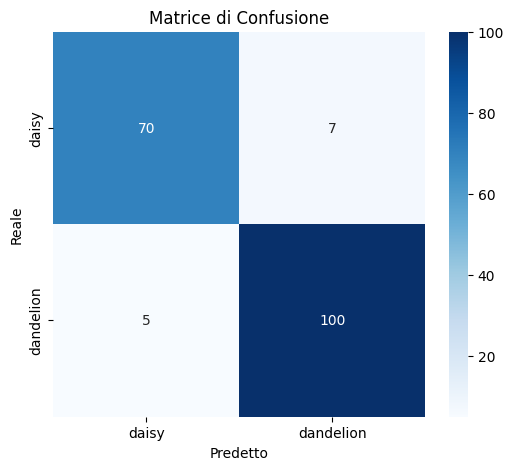

Numero di errori rilevati: 12


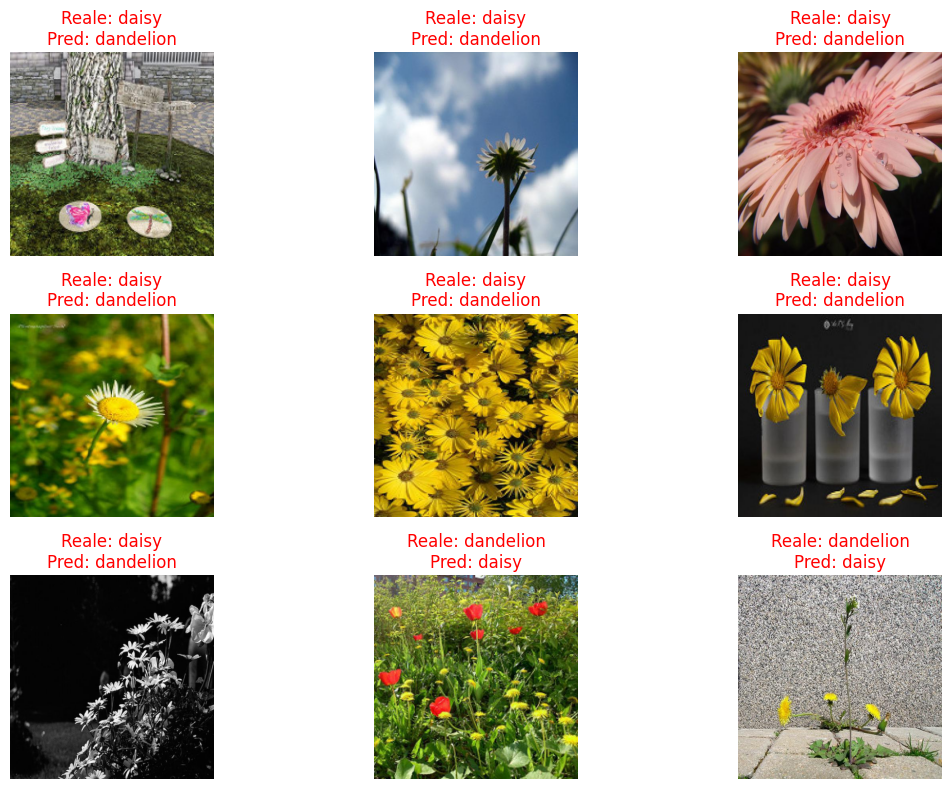

In [12]:
def inference(model: nn.Module, loader: DataLoader, device: torch.device) -> Tuple[np.ndarray, np.ndarray]:
    """Ottiene tutte le predizioni dal modello.

    Args:
        model (nn.Module): modello PyTorch
        loader (DataLoader): DataLoader di PyTorch
        device (torch.device): device di PyTorch (CPU o GPU)

    Returns:
        Tuple[np.ndarray, np.ndarray]: predizioni e targets
    """
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch in loader:
            x, target = batch
            x, target = x.to(device), target.to(device)
            output = model(x)
            all_preds.extend(output.argmax(1).cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    return np.array(all_preds), np.array(all_targets)

def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, class_map: Dict[int, List[str]]) -> None:
    """Disegna la matrice di confusione.

    Args:
        y_true (np.ndarray): array con i target reali
        y_pred (np.ndarray): array con le predizioni
        class_map (Dict[int, List[str]]): mappa delle classi
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    # labels estrae i nomi delle classi dal nostro class_map
    labels = [class_map[i][0] for i in range(len(class_map))]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predetto')
    plt.ylabel('Reale')
    plt.title('Matrice di Confusione')
    plt.show()

def plot_misclassified_images(y_true: np.ndarray, y_pred: np.ndarray, dataset: FlowerDataset, class_map: Dict[int, List[str]], rows: int = 3, cols: int = 3) -> None:
    """Visualizza le immagini dove il modello ha sbagliato.

    Args:
        y_true (np.ndarray): array con i target reali
        y_pred (np.ndarray): array con le predizioni
        dataset (FlowerDataset): dataset PyTorch
        class_map (Dict[int, List[str]]): mappa delle classi
        rows (int, optional): numero di righe, impostato di default a 2.
        cols (int, optional): numero di colonne, impostato di default a 3.
    """

    misclassified_indices = np.where(y_true != y_pred)[0]

    if len(misclassified_indices) == 0:
        print("Nessuna immagine classificata erroneamente.")
        return

    print(f"Numero di errori rilevati: {len(misclassified_indices)}")

    fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
    # Prendo solo i primi errori disponibili per riempire la griglia
    for i in range(rows):
        for j in range(cols):
            idx_in_misclassified = i * cols + j
            if idx_in_misclassified >= len(misclassified_indices):
                axes[i, j].axis('off')
                continue

            idx = misclassified_indices[idx_in_misclassified]
            # Recupero l'immagine originale per vederla meglio
            img_path = dataset.images[idx]
            image = Image.open(img_path).convert("RGB")

            axes[i, j].imshow(image)
            axes[i, j].set_title(f"Reale: {class_map[y_true[idx]][0]}\nPred: {class_map[y_pred[idx]][0]}", color='red')
            axes[i, j].axis('off')

    plt.tight_layout()
    plt.show()

# --- ESEGUO L'ANALISI ---
y_pred, y_true = inference(model, test_loader, device)
plot_confusion_matrix(y_true, y_pred, class_map)
plot_misclassified_images(y_true, y_pred, test_dataset, class_map)